## MNIST DATASET
### -> CNN implementation using pytorch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

| Import                        | Purpose                                              |
| ----------------------------- | ---------------------------------------------------- |
| `torch`                       | Core library (tensors, GPU support, autograd)        |
| `torch.nn`                    | Neural network layers & losses (with parameters)     |
| `torch.nn.functional`         | Stateless functions (activations, pooling)           |
| `torch.optim`                 | Optimizers (SGD, Adam, etc.)                         |
| `torchvision.datasets`        | Pre-built datasets for computer vision               |
| `torchvision.transforms`      | Preprocessing utilities (normalize, resize, augment) |
| `torch.utils.data.DataLoader` | Batching & shuffling data for training               |


We normalize MNIST images to range [0,1] → [-1,1] for faster convergence.

In [2]:
# Transform: convert to tensor + normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean=0.5, std=0.5
])

# Download & load dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

CNN with two convolutional layers + two fully connected layers.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolution layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)  # output: 26x26x32
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3) # output: 24x24x64
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128)  # 5x5 after pooling
        self.fc2 = nn.Linear(128, 10)  # 10 output classes (digits 0-9)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)  # reduce size to 13x13
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)  # reduce size to 5x5
        x = x.view(-1, 64 * 5 * 5) # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Loss Function & Optimizer

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Model training

In [5]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()           # Zero the gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels) # Loss calculation
        loss.backward()                 # Backpropagation
        optimizer.step()                # Update weights

        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.1446
Epoch [2/5], Loss: 0.0448
Epoch [3/5], Loss: 0.0316
Epoch [4/5], Loss: 0.0236
Epoch [5/5], Loss: 0.0166


Evaluate

In [6]:
import torchmetrics

# Define accuracy metric
accuracy = torchmetrics.classification.MulticlassAccuracy(num_classes=10)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        accuracy.update(preds, labels)

print(f"Test Accuracy: {accuracy.compute().item()*100:.2f}%")


Test Accuracy: 99.01%


Predicting for One single image

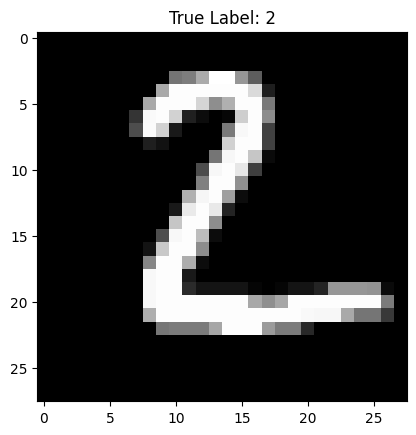

Predicted Label: 2


In [7]:
import matplotlib.pyplot as plt

# Take one sample
image, label = test_dataset[1]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True Label: {label}")
plt.show()

# Model prediction
model.eval()
with torch.no_grad():
    image = image.unsqueeze(0)  # add batch dimension
    output = model(image)
    pred = output.argmax(dim=1).item()
    print(f"Predicted Label: {pred}")
